Importing Required Libraries

In [32]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

Helper Function for Visualisation

In [33]:
def visualize_statevector(circuit, title="Statevector"):
    # Visualize the quantum state as a probability bar chart
    simulator = AerSimulator()
    circuit.save_statevector()
    result = simulator.run(circuit).result()
    statevector = result.get_statevector(circuit)
    
    # Create bar chart
    n_qubits = circuit.num_qubits
    num_states = 2 ** n_qubits
    states = [format(i, f'0{n_qubits}b') for i in range(num_states)]
    probs = np.abs(statevector) ** 2
    
    plt.figure(figsize=(14, 6))
    bars = plt.bar(states, probs, color='#1f77b4')
    plt.title(title)
    plt.xlabel('State')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    
    # Add value labels on top of bars
    for bar, prob in zip(bars, probs):
        if prob > 0.01:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{prob:.3f}', ha='center', va='bottom')
    
    plt.show()
    
    print(f"Statevector: {statevector}")
    return statevector

The CNOT (Controlled-NOT) Gate

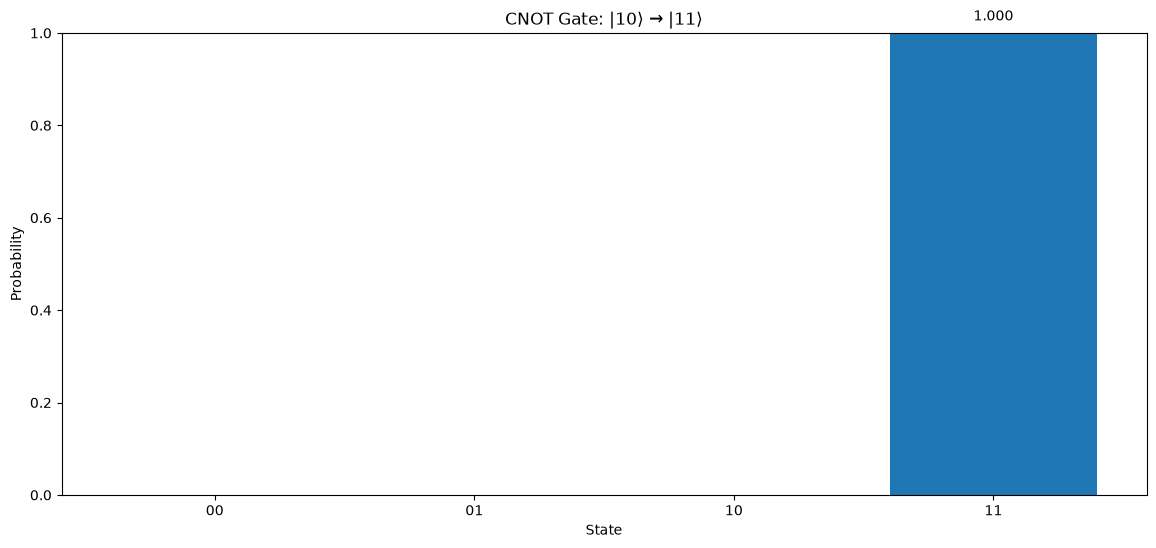

Statevector: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


In [34]:
# Create a 2-qubit circuit
qc_cnot = QuantumCircuit(2)

# Initialize the state |10⟩ (qubit 0 is control, qubit 1 is target)
# We start with |00⟩, then flip qubit 0 to |1⟩
qc_cnot.x(0)

# Apply CNOT with qubit 0 as control and qubit 1 as target
qc_cnot.cx(0, 1)

# Visualize the statevector
state = visualize_statevector(qc_cnot, "CNOT Gate: |10⟩ → |11⟩")

Example: CNOT with Control in |0⟩

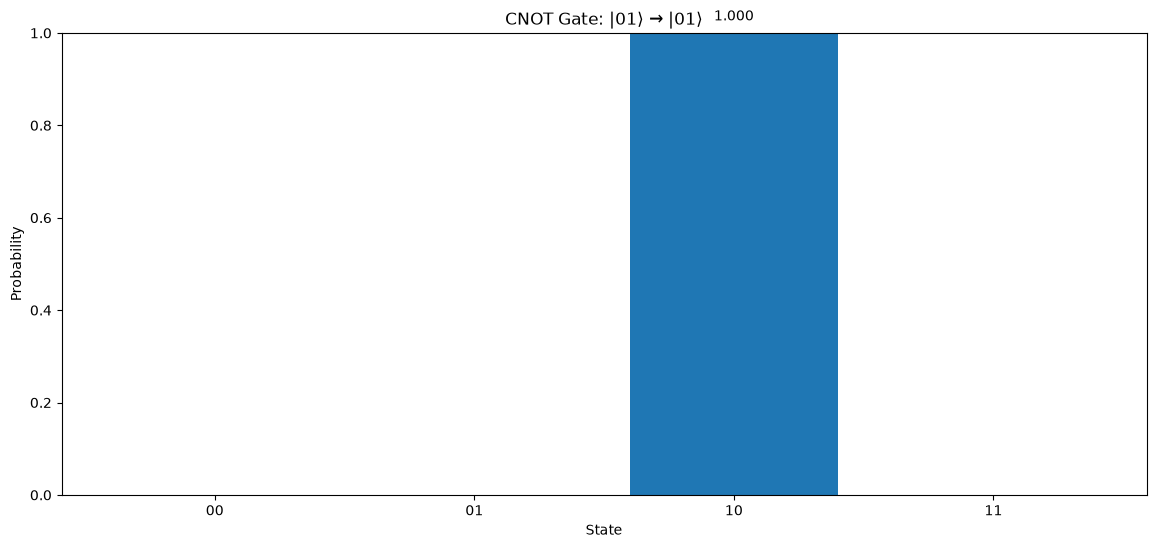

Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


In [35]:
# Create a 2-qubit circuit
qc_cnot_2 = QuantumCircuit(2)

# Start with |01⟩ (qubit 0 is 0, qubit 1 is 1)
qc_cnot_2.x(1)

# Apply CNOT with qubit 0 as control and qubit 1 as target
qc_cnot_2.cx(0, 1)

# Visualize the statevector
state = visualize_statevector(qc_cnot_2, "CNOT Gate: |01⟩ → |01⟩")

The CZ (Controlled‑Z) Gate

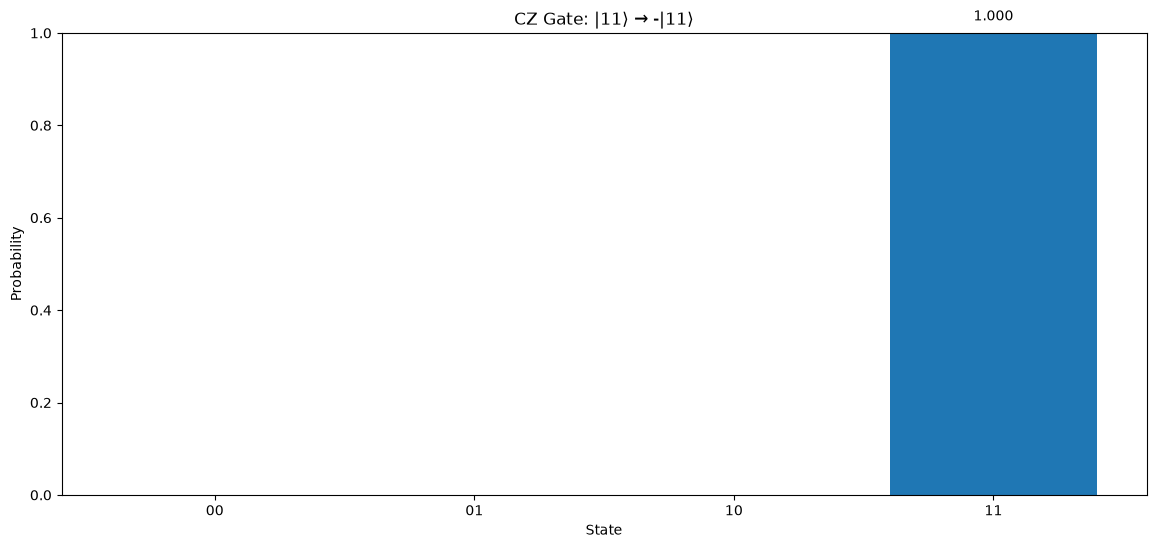

Statevector: Statevector([ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
            dims=(2, 2))


In [36]:
# Create a 2-qubit circuit
qc_cz = QuantumCircuit(2)

# Start with |11⟩ (both qubits in |1⟩)
qc_cz.x(0)
qc_cz.x(1)

# Apply CZ gate
qc_cz.cz(0, 1)

# Visualize the statevector
state = visualize_statevector(qc_cz, "CZ Gate: |11⟩ → -|11⟩")

Example: CZ with Control in |0⟩

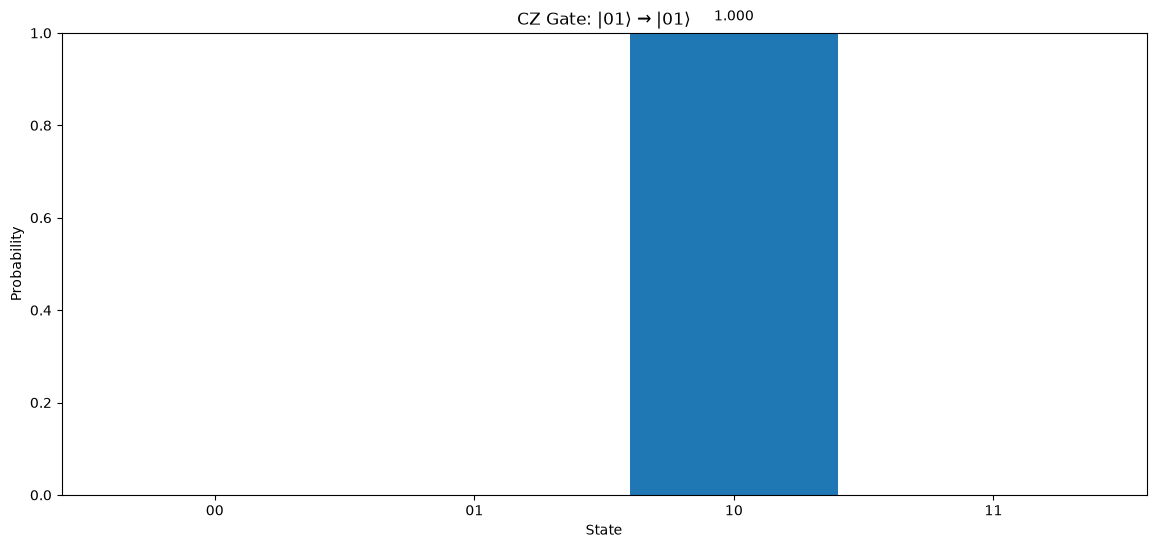

Statevector: Statevector([ 0.+0.j,  0.+0.j,  1.+0.j, -0.+0.j],
            dims=(2, 2))


In [37]:
# Create a 2-qubit circuit
qc_cz_2 = QuantumCircuit(2)

# Start with |01⟩ (qubit 0 is 0, qubit 1 is 1)
qc_cz_2.x(1)

# Apply CZ gate
qc_cz_2.cz(0, 1)

# Visualize the statevector
state = visualize_statevector(qc_cz_2, "CZ Gate: |01⟩ → |01⟩")

The SWAP Gate

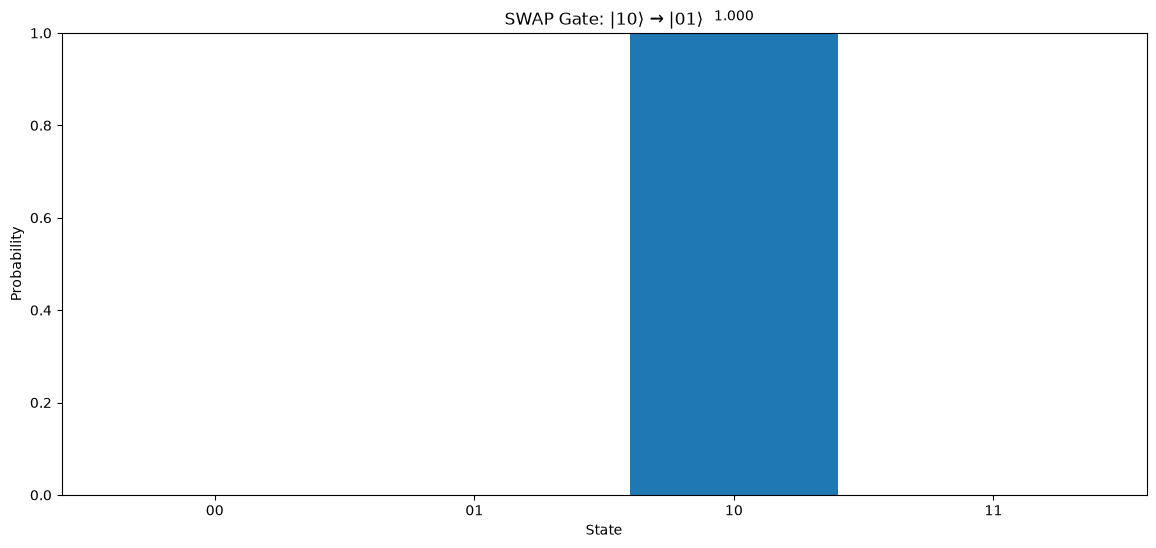

Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


In [38]:
# Create a 2-qubit circuit
qc_swap = QuantumCircuit(2)

# Start with |10⟩
qc_swap.x(0)

# Apply SWAP gate
qc_swap.swap(0, 1)

# Visualize the statevector
state = visualize_statevector(qc_swap, "SWAP Gate: |10⟩ → |01⟩")

Example: SWAP with |01⟩

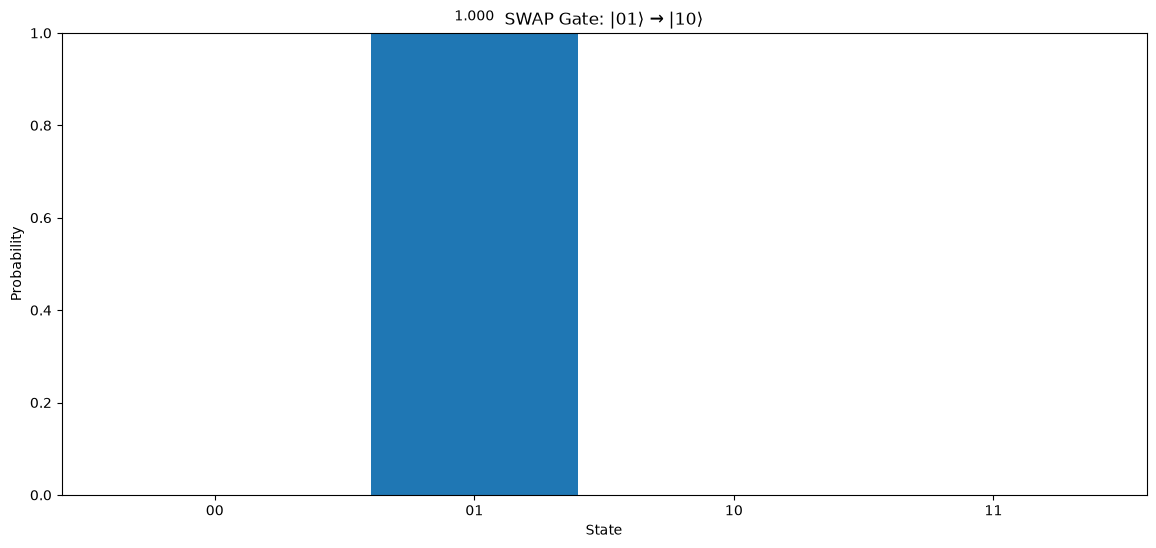

Statevector: Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [39]:
# Create a 2-qubit circuit
qc_swap_2 = QuantumCircuit(2)

# Start with |01⟩
qc_swap_2.x(1)

# Apply SWAP gate
qc_swap_2.swap(0, 1)

# Visualize the statevector
state = visualize_statevector(qc_swap_2, "SWAP Gate: |01⟩ → |10⟩")

Visualising All Gates Together

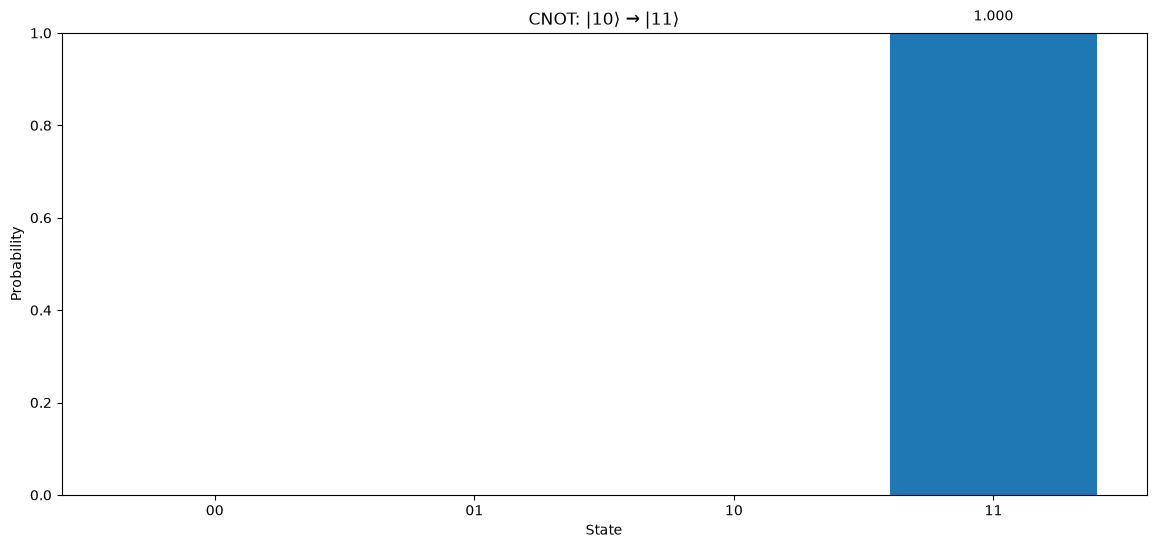

Statevector: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))



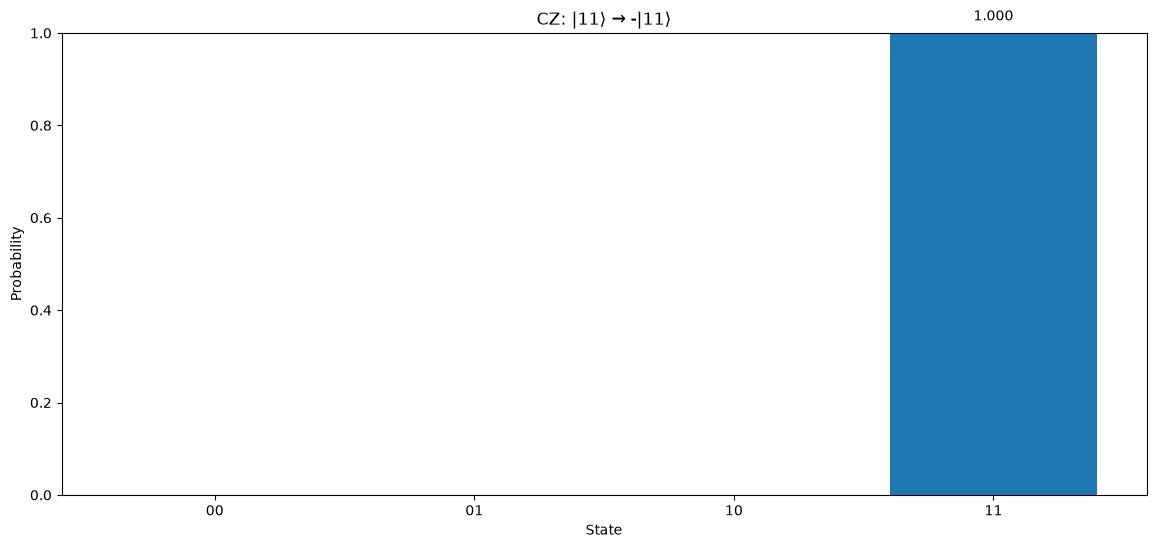

Statevector: Statevector([ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
            dims=(2, 2))



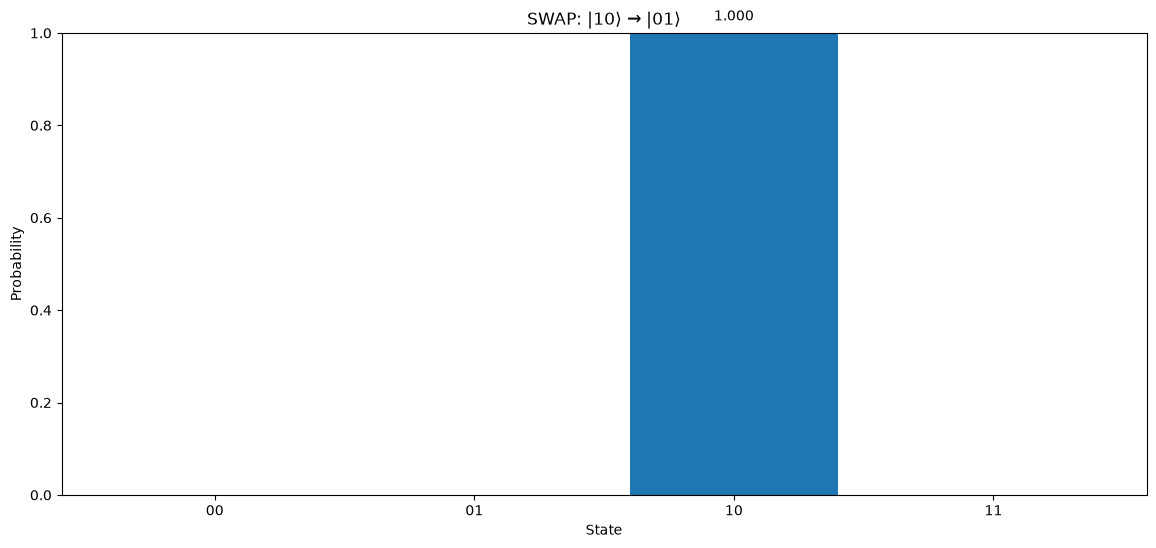

Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))



In [40]:
# Define base circuits
gates = [
    ("CNOT: |10⟩ → |11⟩", QuantumCircuit(2)),
    ("CZ: |11⟩ → -|11⟩", QuantumCircuit(2)),
    ("SWAP: |10⟩ → |01⟩", QuantumCircuit(2)),
]

# Apply operations
# CNOT
gates[0][1].x(0)
gates[0][1].cx(0, 1)

# CZ
gates[1][1].x(0)
gates[1][1].x(1)
gates[1][1].cz(0, 1)

# SWAP
gates[2][1].x(0)
gates[2][1].swap(0, 1)

# Initialize simulator
simulator = AerSimulator()

# Simulate and display each statevector
for label, circuit in gates:
    circ_copy = circuit.copy()
    circ_copy.save_statevector()
    
    result = simulator.run(circ_copy).result()
    statevector = result.get_statevector(circ_copy)
    
    # Create bar chart
    n_qubits = circ_copy.num_qubits
    num_states = 2 ** n_qubits
    states = [format(i, f'0{n_qubits}b') for i in range(num_states)]
    probs = np.abs(statevector) ** 2
    
    plt.figure(figsize=(14, 6))
    bars = plt.bar(states, probs, color='#1f77b4')
    plt.title(label)
    plt.xlabel('State')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    
    for bar, prob in zip(bars, probs):
        if prob > 0.01:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{prob:.3f}', ha='center', va='bottom')
    
    plt.show()
    print(f"Statevector: {statevector}\n")